In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import glob

#################
# Loading Dataset
#################
path = '/content/drive/MyDrive/CICIoV2024/*.csv'
files = glob.glob(path)

# Merging csvs
dfs = []
for f in files:
    dfs.append(pd.read_csv(f))

df = pd.concat(dfs, ignore_index=True)
print(df.shape)

(11859068, 13)


In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

####################
# Data Preprocessing
####################
# Dropping nan and inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Dropping unnecessary columns
X = df.drop(columns=['ID', 'label', 'category', 'specific_class','source'])
feature_names = X.columns.tolist()

# Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Binary Class Label Encoder
le_binary = LabelEncoder()
y_binary = le_binary.fit_transform(df['label'])

# Multi Class Label Encoder
le_multi = LabelEncoder()
y_multi = le_multi.fit_transform(df['specific_class'])

print("Classes (binary):", le_binary.classes_)
print("Classes (multiclass):", le_multi.classes_)
print("X shape:", X_scaled.shape)

Classes (binary): ['ATTACK' 'BENIGN']
Classes (multiclass): ['DoS' 'NORMAL' 'RPM']
X shape: (6137270, 8)


In [8]:
##################
# Train test split
##################
# 70% training 30% testing
X_train, X_test, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4296089, 8)
Test size: (1841181, 8)


In [9]:

# Reshape for CNN
X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_r = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_mr = X_train_m.reshape(X_train_m.shape[0], X_train_m.shape[1], 1)
X_test_mr = X_test_m.reshape(X_test_m.shape[0], X_test_m.shape[1], 1)

print("Reshaped train:", X_train_r.shape)

Reshaped train: (4296089, 8, 1)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.keras.mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(True)

def build_cnn_attn_gru(num_features, output_units, activation):
    inp = layers.Input(shape=(num_features, 1))

    # CNN blocks: 32 filters
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(inp)
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)

    # Multihead Attention Layer
    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=8
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # GRU Layer
    x = layers.GRU(
        48,
        return_sequences=True,
        recurrent_dropout=0.0
    )(x)

    x = layers.Dropout(0.15)(x)

    x = layers.GRU(
        24,
        recurrent_dropout=0.0
    )(x)

    # Dense head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(
        output_units,
        activation=activation,
        dtype='float32'
    )(x)

    return models.Model(inp, out)

num_features = X_train.shape[1]

model_binary = build_cnn_attn_gru(num_features, 1, 'sigmoid')

model_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_binary.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 8, 32)     │      3,104 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 32)     │      2,128 │ conv1d_5[0][0],   │
│ (MultiHeadAttentio… │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 32)     │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 32)     │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 8, 48)     │     11,808 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 8, 48)     │          0 │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ (None, 24)        │      5,328 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      1,600 │ gru_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,225 (94.63 KB)

 Trainable params: 24,225 (94.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

#######################
# Training Binary Model
#######################
es_binary = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_binary = model_binary.fit(
    X_train_r, y_train_b,
    validation_data=(X_test_r, y_test_b),
    epochs=20,
    batch_size=512,
    callbacks=[es_binary]
)


Epoch 1/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 100s 11ms/step - accuracy: 0.9319 - loss: 0.1051 - val_accuracy: 0.9305 - val_loss: 0.1015
Epoch 2/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 92s 11ms/step - accuracy: 0.9340 - loss: 0.0996 - val_accuracy: 0.9389 - val_loss: 0.0971
Epoch 3/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.9316 - loss: 0.1012 - val_accuracy: 0.9389 - val_loss: 0.0951
Epoch 4/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.9361 - loss: 0.0973 - val_accuracy: 0.9389 - val_loss: 0.0950
Epoch 5/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.9362 - loss: 0.0973 - val_accuracy: 0.9389 - val_loss: 0.0950
Epoch 6/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.9385 - loss: 0.0953 - val_accuracy: 0.9389 - val_loss: 0.0971


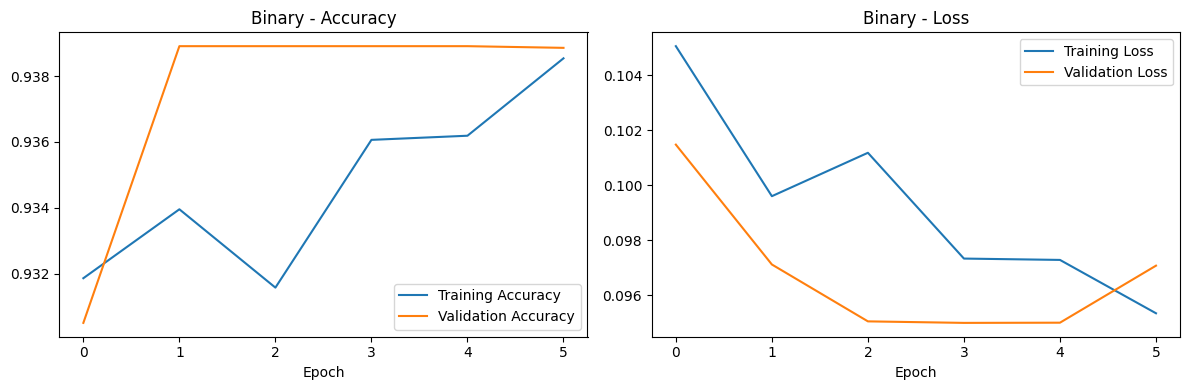

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

##########################
# Plotting Training curves
##########################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_binary.history['accuracy'], label='Training Accuracy')
ax1.plot(history_binary.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Binary - Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_binary.history['loss'], label='Training Loss')
ax2.plot(history_binary.history['val_loss'], label='Validation Loss')
ax2.set_title('Binary - Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('binary_training_curves.png', dpi=150)
plt.show()

57537/57537 ━━━━━━━━━━━━━━━━━━━━ 148s 3ms/step
              precision    recall  f1-score   support

      ATTACK       0.93      1.00      0.96   1516918
      BENIGN       1.00      0.65      0.79    324263

    accuracy                           0.94   1841181
   macro avg       0.97      0.83      0.88   1841181
weighted avg       0.94      0.94      0.93   1841181



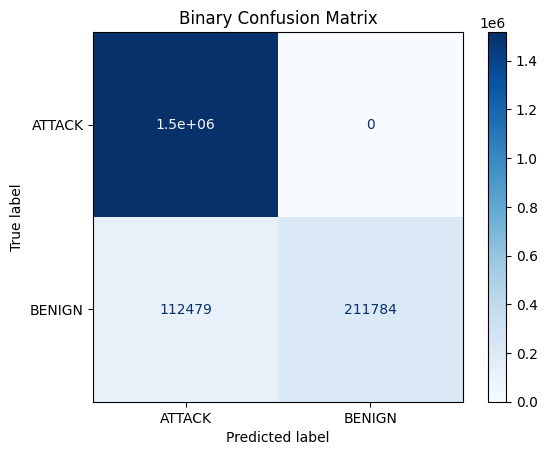

ROC AUC: 0.8266


In [17]:
############################################
# Classification Report and Confusion Matrix
############################################

# Predictions
y_pred_b = (model_binary.predict(X_test_r) > 0.5).astype(int).flatten()

# Classification report
print(classification_report(y_test_b, y_pred_b, target_names=le_binary.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_binary.classes_)
disp.plot(cmap='Blues')
plt.title('Binary Confusion Matrix')
plt.savefig('binary_confusion_matrix.png', dpi=150)
plt.show()

# ROC AUC
auc = roc_auc_score(y_test_b, y_pred_b)
print(f"ROC AUC: {auc:.4f}")

In [18]:
###########################
# Training MultiClass Model
###########################
num_classes = len(le_multi.classes_)
model_multi = build_cnn_attn_gru(X_train_m.shape[1], num_classes, 'softmax')
model_multi.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es_multi = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_multi = model_multi.fit(
    X_train_mr, y_train_m,
    validation_data=(X_test_mr, y_test_m),
    epochs=20,
    batch_size=512,
    callbacks=[es_multi]
)


Epoch 1/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 107s 12ms/step - accuracy: 0.7488 - loss: 0.4990 - val_accuracy: 0.7358 - val_loss: 0.5150
Epoch 2/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 141s 12ms/step - accuracy: 0.7513 - loss: 0.4942 - val_accuracy: 0.7578 - val_loss: 0.4732
Epoch 3/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 100s 12ms/step - accuracy: 0.7567 - loss: 0.4791 - val_accuracy: 0.7544 - val_loss: 0.4839
Epoch 4/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 98s 12ms/step - accuracy: 0.7588 - loss: 0.4749 - val_accuracy: 0.7606 - val_loss: 0.4663
Epoch 5/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 141s 11ms/step - accuracy: 0.7594 - loss: 0.4733 - val_accuracy: 0.7574 - val_loss: 0.4743
Epoch 6/20
8391/8391 ━━━━━━━━━━━━━━━━━━━━ 93s 11ms/step - accuracy: 0.7591 - loss: 0.4762 - val_accuracy: 0.7619 - val_loss: 0.4705


57537/57537 ━━━━━━━━━━━━━━━━━━━━ 155s 3ms/step
              precision    recall  f1-score   support

         DoS       0.70      0.36      0.48    413471
      NORMAL       0.69      1.00      0.82    324263
         RPM       0.80      0.84      0.82   1103447

    accuracy                           0.76   1841181
   macro avg       0.73      0.73      0.71   1841181
weighted avg       0.76      0.76      0.74   1841181



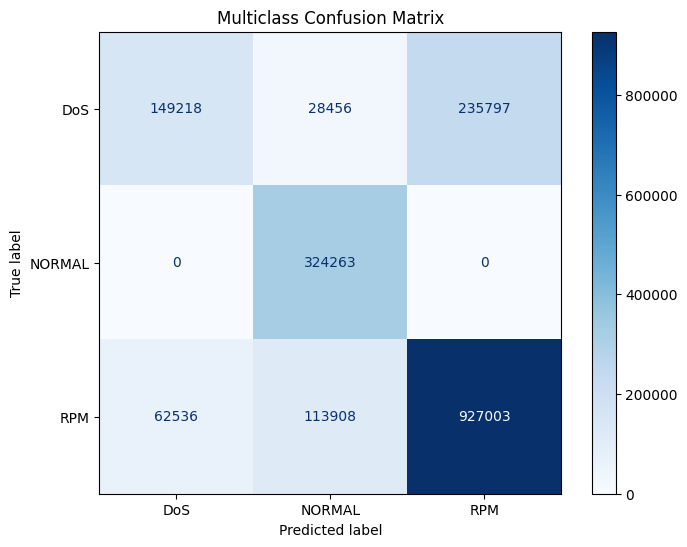

In [19]:
#############################
# Evaluating MultiClass Model
#############################
y_pred_m = np.argmax(model_multi.predict(X_test_mr), axis=1)

print(classification_report(y_test_m, y_pred_m, target_names=le_multi.classes_))

cm_m = confusion_matrix(y_test_m, y_pred_m)
disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_m, display_labels=le_multi.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp_m.plot(cmap='Blues', ax=ax)
plt.title('Multiclass Confusion Matrix')
plt.savefig('multiclass_confusion_matrix.png', dpi=150)
plt.show()

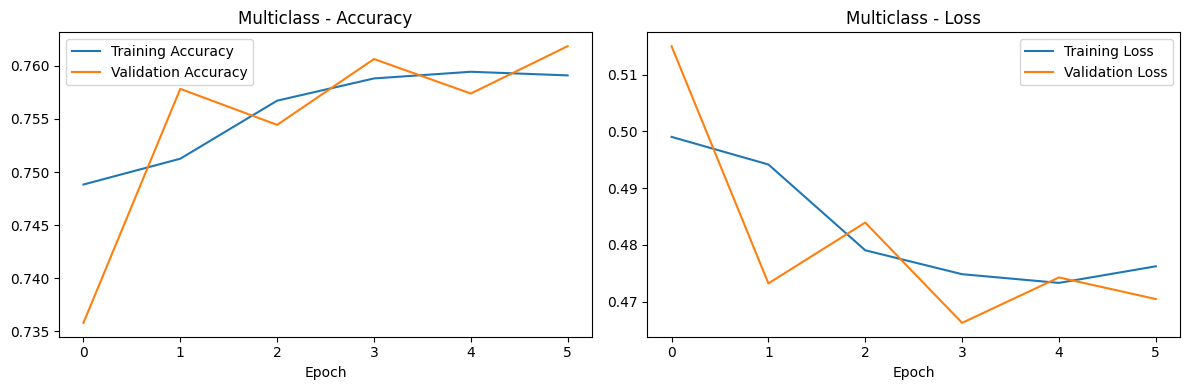

In [20]:
#####################################
# Plotting MultiClass Training Curves
#####################################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_multi.history['accuracy'], label='Training Accuracy')
ax1.plot(history_multi.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Multiclass - Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_multi.history['loss'], label='Training Loss')
ax2.plot(history_multi.history['val_loss'], label='Validation Loss')
ax2.set_title('Multiclass - Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('multiclass_training_curves.png', dpi=150)
plt.show()

In [21]:
!pip install shap -q
import shap

####################
# SHAP Configuration
####################
background_r = X_train_r[:100]
test_r = X_test_r[:200]

explainer = shap.GradientExplainer(model_binary, background_r)
shap_values = explainer.shap_values(test_r)

if isinstance(shap_values, list):
    sv = shap_values[0]
else:
    sv = shap_values

# Cast to float32 — mixed precision produces float16 which matplotlib can't handle
shap_flat = sv.squeeze(-1).astype('float32') if sv.ndim == 3 else sv.astype('float32')
test_flat  = test_r.squeeze(-1).astype('float32')


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_33
Received: inputs=['Tensor(shape=(200, 8, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_33
Received: inputs=['Tensor(shape=(50, 8, 1))']
  warnings.warn(msg)


mean_shap shape: (8,)
sorted_idx shape: (8,)


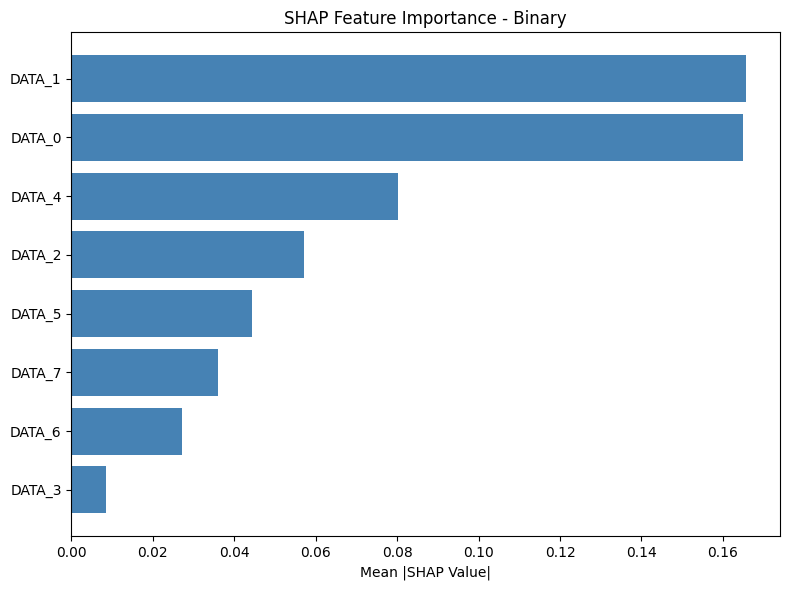

In [22]:
###################
# SHAP Summary Plot
###################
import matplotlib.pyplot as plt
import numpy as np

feature_names_arr = np.array(feature_names)

# Flatten to 1-D
mean_shap = np.abs(shap_flat).mean(axis=0).flatten()
sorted_idx = np.argsort(mean_shap).flatten()

# Display Shape
print("mean_shap shape:", mean_shap.shape)
print("sorted_idx shape:", sorted_idx.shape)

# Convert to List
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    feature_names_arr[sorted_idx].tolist(),
    mean_shap[sorted_idx].tolist(),
    color='steelblue'
)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Feature Importance - Binary')
plt.tight_layout()
plt.savefig('shap_binary_summary.png', dpi=150, bbox_inches='tight')
plt.show()

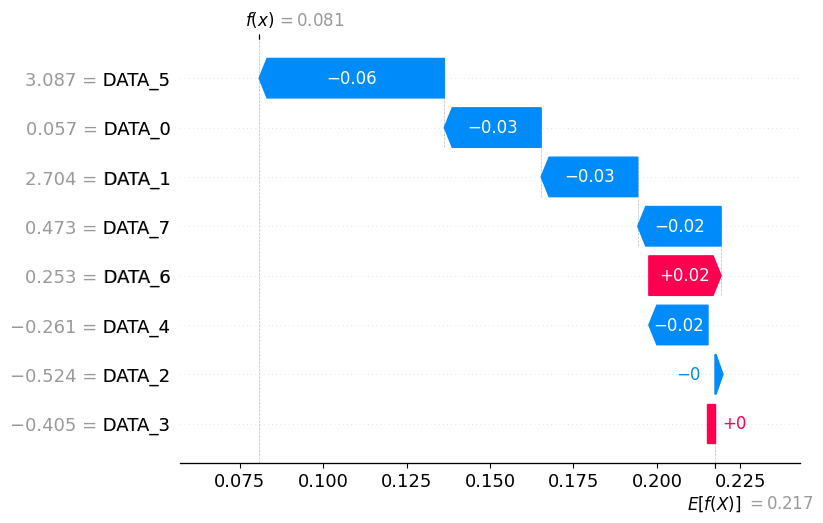

<Figure size 640x480 with 0 Axes>

In [23]:
################
# Waterfall Plot
################
import numpy as np

# GradientExplainer
base_value = float(model_binary.predict(background_r, verbose=0).mean())

shap.plots.waterfall(
    shap.Explanation(
        values=shap_flat[0].flatten(),
        base_values=base_value,
        data=test_flat[0].flatten(),
        feature_names=feature_names
    )
)
plt.savefig('shap_waterfall_binary.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
import shutil

###########################
# Saving all plots to drive
###########################
shutil.copy('binary_training_curves.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('binary_confusion_matrix.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('multiclass_confusion_matrix.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('multiclass_training_curves.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('shap_binary_summary.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('shap_waterfall_binary.png', '/content/drive/MyDrive/CICIoV2024/')

'/content/drive/MyDrive/CICIoV2024/shap_waterfall_binary.png'

In [25]:
import json

#################
# Experiment Logs
#################
logs = {
    "binary": {
        "accuracy": history_binary.history['accuracy'],
        "val_accuracy": history_binary.history['val_accuracy'],
        "loss": history_binary.history['loss'],
        "val_loss": history_binary.history['val_loss']
    },
    "multiclass": {
        "accuracy": history_multi.history['accuracy'],
        "val_accuracy": history_multi.history['val_accuracy'],
        "loss": history_multi.history['loss'],
        "val_loss": history_multi.history['val_loss']
    }
}

with open('/content/drive/MyDrive/CICIoV2024/experiment_logs_2.json', 'w') as f:
    json.dump(logs, f, indent=2)

print("Logs saved.")

Logs saved.
